# Redes Neuronales: segunda parte

## Datos no estructurados, redes convolucionales, transfer learning y modelos generativos

## Agenda

1. **Datos no estructurados**: qué son, cómo se representan y por qué son difíciles
2. **Redes convolucionales (CNN)**: filtros, feature maps, padding, stride, pooling, dropout
3. **CNN Explainer**: recorrido interactivo de una red completa
4. *Corte*
5. **CNN en Keras**: una red real, de punta a punta
6. **Data augmentation** y **transfer learning**
7. **Modelos generativos en NLP**: nociones básicas de los LLMs

# Datos no estructurados

## Hasta ahora: datos estructurados

| pasajero | edad | sexo | clase | tarifa | sobrevivió |
|---|---|---|---|---|---|
| 1 | 22 | M | 3 | 7.25 | 0 |
| 2 | 38 | F | 1 | 71.28 | 1 |
| 3 | 26 | F | 3 | 7.92 | 1 |

* Cada **columna** es una feature con **significado propio** ("edad", "tarifa")
* Cantidad **fija** de columnas para todos los ejemplos
* El **orden** de las columnas no importa
* Alguien (nosotros) ya decidió qué información es relevante

## Datos no estructurados

Imágenes, videos, audio, texto... la **mayor parte** de los datos que se generan en el mundo.

* No hay columnas con significado: hay **muchísimos valores crudos** (píxeles, muestras, caracteres)
* Un valor aislado **no significa nada**: ¿qué nos dice que el píxel (120, 45) valga 213?
* La información está en las **relaciones** entre valores: formas, sonidos, palabras, contexto

## Imágenes

![](images/unstructured_image_tensor.png)

* Una imagen es un **tensor** de forma `(alto, ancho, canales)`
* Color: 3 canales (RGB). Escala de grises: 1 canal
* Cada valor es la intensidad de un canal en un píxel: entero entre 0 y 255 (normalmente lo escalamos a [0, 1])

## Video

![](images/unstructured_video_frames.png)

* Un video es una **secuencia de imágenes** (frames): tensor `(tiempo, alto, ancho, canales)`
* Se suma la dimensión **temporal**: el movimiento no está en ningún frame, está en **el cambio entre frames**
* Suele venir acompañado de audio

## Audio

![](images/unstructured_audio_waveform.png)

* El sonido es una onda de presión: el micrófono la **muestrea** muchas veces por segundo
* **Sample rate**: 16.000 Hz (voz), 44.100 Hz (música en CD) → 1 minuto de música ≈ 2,6 millones de números
* Es una serie de tiempo **muy larga** y de una sola dimensión

### Del tiempo a la frecuencia: espectrograma

<div><img src="images/fourier_transform_idea.gif" width="45%" style="float: left; margin: 10px;"></div>

* Un sonido se puede descomponer en una suma de **frecuencias** (transformada de Fourier)
* Si lo hacemos por ventanas de tiempo obtenemos un **espectrograma**: tiempo en x, frecuencia en y, intensidad como color
* Resultado: el audio pasa a ser... **una imagen**

<div style="clear:both;"></div>

![](images/himno_spectrogram.png)

## Texto

![](images/unstructured_text_tokens.png)

* El texto es una **secuencia** de largo **variable** de símbolos discretos
* Se parte en **tokens** (palabras o pedazos de palabras), y cada token se mapea a un **id** de un vocabulario
* Los ids son arbitrarios: que "clase" sea 9821 no dice nada. Por eso se convierten en **vectores** (embeddings) que se aprenden
* El significado depende del **contexto**: "me senté en el *banco*" vs "fui al *banco* a pagar"

### Embeddings: palabras como vectores

<div><img src="images/word_embeddings.png" width="35%" style="float: left; margin: 10px;"></div>

* Cada token se representa con un vector de cientos de números
* Se aprenden de forma que palabras usadas en contextos parecidos queden **cerca**
* Es la misma idea que vamos a ver en las CNN: **la red aprende la representación**, no se la damos hecha

<div style="clear:both;"></div>

## Resumen: cómo están compuestos

| Tipo | Representación | Forma del tensor | Ejemplo de tamaño | Estructura que importa |
|---|---|---|---|---|
| Imagen | píxeles | `(alto, ancho, canales)` | 224x224x3 ≈ 150 mil | **espacial** (vecinos) |
| Video | frames | `(tiempo, alto, ancho, canales)` | 10 s en 1080p ≈ 1.900 millones | **espacial + temporal** |
| Audio | muestras / espectrograma | `(muestras,)` o `(frecuencia, tiempo)` | 1 min a 44,1 kHz ≈ 2,6 millones | **temporal** / frecuencias |
| Texto | tokens → embeddings | `(tokens, dimensión)` | largo variable | **secuencial** y de contexto |

## ¿Qué cambia para hacer ML?

Pregunta: si a una tabla le **mezclamos el orden de las columnas**, ¿perdemos información? ¿Y si a una imagen le **mezclamos los píxeles**?

* En la tabla: no perdemos nada, el modelo aprende lo mismo
* En la imagen: perdemos **todo**. La información está en **qué valor está al lado de cuál**

## Las complejidades de modelar con estos datos (1/2)

* **No hay features definidas**: con datos tabulares el feature engineering parte de columnas con significado. Acá hay que **construir** (o aprender) las features desde valores crudos
* **Altísima dimensionalidad**: una imagen chica de 224x224x3 son 150.528 inputs. Una red densa con 1.000 neuronas en la primera capa tendría **150 millones de pesos** solo ahí
* **La estructura local importa**: píxeles vecinos, muestras consecutivas, palabras cercanas. Un modelo que trata cada input como independiente la desperdicia

## Las complejidades de modelar con estos datos (2/2)

* **Variabilidad / invariancias**: el mismo objeto en otra posición, escala, iluminación o ángulo produce valores **completamente distintos**
* **Tamaño variable**: imágenes de distintas resoluciones, audios de distinta duración, textos de distinto largo
* **Costo**: se necesitan muchos ejemplos etiquetados (etiquetar imágenes o audio a mano es caro) y mucho cómputo (GPUs)

### Mismo objeto, valores muy distintos

![](images/CV_intro_3.PNG)

![](images/CV_intro_4.PNG)

### Incluso un desplazamiento mínimo cambia todo

![](images/cnn_shift_problem.png)

Para un modelo que mira cada input por separado (regresión logística, árboles, una red densa), estos dos "7" son **ejemplos muy distintos**.

## ¿Cómo se trabajaba antes? Enfoque tradicional

![](images/CV_approach_1.PNG)

Un experto diseñaba a mano un **extractor de features**, y sobre esas features se entrenaba un modelo "clásico" (SVM, random forest, regresión logística...).

| Datos | Features "a mano" | Modelo típico |
|---|---|---|
| Imágenes | bordes (Sobel, Canny), histogramas de color, HOG, SIFT | SVM. Ej: detección de caras (Viola-Jones, 2001), de peatones (HOG + SVM, 2005) |
| Audio | MFCCs, energía, tasa de cruces por cero | GMM / HMM (reconocimiento de voz) |
| Texto | bag of words, TF-IDF, n-gramas | Naive Bayes, regresión logística (filtros de spam) |
| Video | features por frame + flujo óptico (movimiento) | SVM |

**Problemas**: requiere mucho conocimiento del dominio, es frágil ante cambios (luz, ruido, acentos) y hay que rediseñarlo para cada problema.

## Enfoque deep learning

![](images/CV_approach_2.PNG)

* La red recibe los datos **crudos** y **aprende las features** necesarias para la tarea (aprendizaje *end-to-end*)
* Necesita arquitecturas que **aprovechen la estructura** de los datos: convoluciones para lo espacial, secuencias/atención para el texto
* El punto de quiebre: **ImageNet 2012**. Una CNN (AlexNet) bajó el error top-5 de ~26% a ~15%. Desde entonces el deep learning domina en imágenes, audio y texto

# Redes Convolucionales (CNN)

## Motivación

*Un repaso de cómo se vería una red densa*

<div><img src="images/mnist_multilayer.png" width="400" style="float: left; margin: 10px;"></div>

<div style="float: left; margin: 10px;">
    <ul>
      <li>¿Cuántos pesos tiene cada neurona?</li>
      <li>¿Se comparte información entre distintas ubicaciones de la imagen?</li>
      <li>Si el dígito se mueve 2 píxeles, ¿la red lo reconoce?</li>
    </ul>
</div>

<div style="clear:both;"></div>

### La red densa necesita aplanar la imagen

![](images/image_as_input.svg)

Al aplanar **perdemos la estructura espacial**: la red no sabe qué píxeles eran vecinos.

## La idea de la convolución

En vez de mirar toda la imagen de una, usamos un **detector chiquito** (por ejemplo de 3x3) que:

1. mira una **porción local** de la imagen,
2. calcula qué tanto esa porción se parece al patrón que busca,
3. se **desliza** por toda la imagen, aplicando **siempre los mismos pesos**.

Ese detector se llama **filtro** (o **kernel**), y el resultado de aplicarlo en todas las posiciones es un **feature map**.

## ¿Cómo funciona la operación de convolución?

<div><img src="images/conv_explanation.jpg" width="45%" style="float: left; margin: 10px;"></div>

* Multiplicamos elemento a elemento el filtro por la porción de la imagen que tiene debajo
* Sumamos todo (+ un bias) → **un número** del feature map
* Movemos el filtro y repetimos

<div style="clear:both;"></div>

### 1 canal

![](images/conv_animation.gif)

### Implementémosla a mano

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def conv2d(x, kernel, stride=1, padding=0):
    """Convolución 2D de un canal, tal como la calcula una capa convolucional."""
    x = np.pad(x, padding)
    f = kernel.shape[0]
    out_size = (x.shape[0] - f) // stride + 1
    out = np.zeros((out_size, out_size))
    for i in range(out_size):
        for j in range(out_size):
            region = x[i * stride:i * stride + f, j * stride:j * stride + f]
            out[i, j] = (region * kernel).sum()
    return out


x = np.array([  # mitad izquierda oscura, mitad derecha clara
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
])
borde_vertical = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])

conv2d(x, borde_vertical)

array([[0., 3., 3., 0.],
       [0., 3., 3., 0.],
       [0., 3., 3., 0.],
       [0., 3., 3., 0.]])

* Valores altos justo donde está el borde vertical, 0 en las zonas uniformes (con el borde al revés, "claro → oscuro", darían negativos)
* El filtro **detecta un patrón**, y el feature map dice **dónde** aparece ese patrón

### Filtros sobre una imagen real

Antes del deep learning, estos filtros se **diseñaban a mano**:

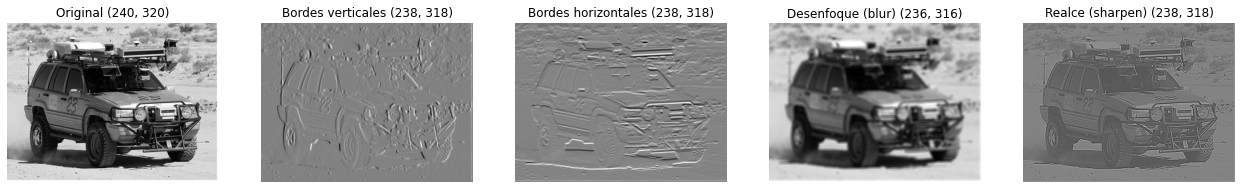

In [2]:
from PIL import Image
from scipy.signal import correlate2d  # correlate2d = lo que hace una capa Conv2D (sin "dar vuelta" el filtro)

img = np.asarray(Image.open("images/cnn_demo_photo.jpg").convert("L"), dtype=float) / 255

filtros = {
    "Bordes verticales": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    "Bordes horizontales": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    "Desenfoque (blur)": np.ones((5, 5)) / 25,
    "Realce (sharpen)": np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
}

fig, axes = plt.subplots(1, len(filtros) + 1, figsize=(22, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"Original {img.shape}")
for ax, (nombre, filtro) in zip(axes[1:], filtros.items()):
    feature_map = correlate2d(img, filtro, mode="valid")
    ax.imshow(feature_map, cmap="gray")
    ax.set_title(f"{nombre} {feature_map.shape}")
for ax in axes:
    ax.axis("off")

En una CNN **no elegimos los números del filtro**: son **pesos** que se **aprenden** con backpropagation, igual que los de una red densa.

### Aplicando un filtro: de imagen a feature map

![](images/applying_filter.gif)

## El filtro como neurona

![](images/convolution_neuron.svg)

* Un filtro es una **neurona** conectada sólo a una porción de la imagen (su *receptive field*)
* Los pesos `p1..p4` son **los mismos** en todas las posiciones
* La salida de esa neurona en todas las posiciones forma un **feature map**

## Varios filtros → varios feature maps

![](images/many_convolutions.svg)

* Cada filtro aprende a detectar un patrón distinto (bordes en distintas direcciones, colores, texturas...)
* Los feature maps se apilan: la salida de la capa tiene **profundidad = cantidad de filtros**

### Feature maps

<div><img src="images/feature_maps.png" width="600" style="margin: 10px;"></div>

* Mantienen la **información espacial**: cada feature map sigue siendo una "imagen", donde se destaca una propiedad particular
* Las capas siguientes trabajan sobre estos mapas, **condensando** información

### 3 canales, 2 filtros

![](images/conv_calculation.png)

* Si la entrada tiene 3 canales, cada filtro tiene **profundidad 3** (un filtro de 3x3 tiene 3x3x3 = 27 pesos + 1 bias)
* Cada filtro produce **un** feature map, sumando sobre todos los canales

https://cs231n.github.io/convolutional-networks/

## Respecto de los problemas planteados originalmente

### Gran cantidad de pesos → conexiones locales

* Si suponemos imágenes de 227x227x3, **cada neurona** de una red densa tendría 154.588 pesos para aprender
* Al conectar las neuronas sólo con una **porción** (receptive field) de la entrada, el número baja drásticamente
  * Por ejemplo, con una porción de 11x11, los pesos de esa neurona son sólo 364 (11x11x3 + 1)
* Ese conjunto de pesos es el **filtro**, y es lo que se **aprende** cuando entrenamos

### Información espacial compartida → pesos compartidos

* Usamos siempre el mismo filtro para generar todo el feature map
* Siguiendo el ejemplo: un feature map de 9x9 = 81 neuronas. Sin compartir pesos serían 364 * 81 = 29.484 pesos. **Compartiendo, sólo 364**
* Bonus: si el patrón aparece en otro lugar, **el mismo filtro lo detecta** → resuelve el problema del "7" desplazado

## Parámetros más comunes de una capa convolucional

* **filters**: cantidad de filtros (= profundidad de la salida). Ej: 32, 64, 128
* **kernel_size F**: tamaño del filtro (ancho y alto; la profundidad la define la entrada). Ej: 3x3, 5x5
* **strides S**: cuántos píxeles se mueve el filtro en cada paso
* **padding P**: agrega ceros en los bordes. `valid` = sin padding (la salida se achica), `same` = el necesario para mantener el tamaño
* **activation**: función de activación aplicada a cada valor del feature map (normalmente ReLU)

Tamaño de salida: **(W - F + 2P) / S + 1**, con W el tamaño de la entrada

Cantidad de pesos: **filters x (F x F x canales_entrada + 1)**

In [3]:
x = np.ones((32, 32))
filtro = np.ones((3, 3))

for padding, stride in [(0, 1), (1, 1), (0, 2), (1, 2)]:
    salida = conv2d(x, filtro, stride=stride, padding=padding)
    print(f"entrada 32x32, filtro 3x3, padding={padding}, stride={stride} -> salida {salida.shape}")

entrada 32x32, filtro 3x3, padding=0, stride=1 -> salida (30, 30)
entrada 32x32, filtro 3x3, padding=1, stride=1 -> salida (32, 32)
entrada 32x32, filtro 3x3, padding=0, stride=2 -> salida (15, 15)
entrada 32x32, filtro 3x3, padding=1, stride=2 -> salida (16, 16)


### Ejercicio rápido

Entrada de 28x28x1 (un dígito de MNIST), capa con 32 filtros de 3x3, stride 1, sin padding.

* ¿Qué forma tiene la salida?
* ¿Cuántos pesos tiene la capa?

* Salida: (28 - 3 + 0) / 1 + 1 = 26 → **26x26x32**
* Pesos: 32 x (3 x 3 x 1 + 1) = **320**

## Pooling

<div><img src="images/max_pooling.png" width="30%" style="float: left; margin: 10px;"></div>

* Reduce el **tamaño espacial** de los feature maps (kernel 2x2 con stride 2 deja el 25% de los valores)
* Menos valores → menos cómputo y menos pesos en las capas siguientes
* Da algo de tolerancia a pequeños desplazamientos y hace más difícil el sobreentrenamiento
* **No hay aprendizaje** (operación fija)
* Trabaja de forma independiente en cada canal. Ej: Input=(4, 4, 3), F=2, S=2 → Output=(2, 2, 3)

La versión más común es **max pooling**. También existe average pooling y *global average pooling* (un valor por feature map)

<div style="clear:both;"></div>

## Dropout

<div><img src="images/dropout.svg" width="35%" style="float: left; margin: 10px;"></div>

* Ya lo vimos en la primera parte: durante el entrenamiento se **apaga** al azar un porcentaje de neuronas
* Obliga a la red a no depender de unas pocas neuronas → **regulariza**, reduce overfitting
* En CNNs se suele usar antes o entre las capas densas finales. Valores típicos: 0.2 a 0.5
* Sólo actúa durante el entrenamiento; al predecir se usan todas las neuronas

<div style="clear:both;"></div>

## Una red completa

Apilamos capas convolucionales: cada una trabaja sobre los feature maps de la anterior

![](images/even_more_convolutions.svg)

En algún momento aplanamos los feature maps para obtener un vector...

![](images/convolutions_to_vector.svg)

...y continuamos con una red densa convencional, que hace la clasificación

![](images/convolutions_plus_mlp.svg)

### El patrón típico

<div><img src="images/neural_network_complete.png" width="100%"></div>

`[Conv → ReLU → (Conv → ReLU) → Pooling] x N → Flatten → Dense → (Dropout) → Dense con softmax`

* A medida que avanzamos: el tamaño espacial **baja** y la cantidad de filtros (profundidad) **sube**
* Parte convolucional = **extractor de features** aprendido. Parte densa = **clasificador**

## Jerarquía de features

Las convoluciones terminan aprendiendo **features** de la imagen **de a poco**, desde conceptos simples a complejos:

* Primeras capas: bordes, colores, texturas
* Capas intermedias: formas, partes (ojos, ruedas, ventanas)
* Últimas capas: objetos completos

Ej: una primera convolución reconoce tipo de terreno en base a píxeles (planta, agua, cemento, arena). La siguiente reconoce ciudad/playa/bosque/desierto en base a los tipos de terreno y su posición (ej: agua + arena = playa). La siguiente reconoce la región del país, en base a cuántas playas, bosques, ciudades, etc. ve en las salidas de la anterior.

# Deep learning?

*The hierarchy of concepts enables the computer to learn complicated concepts by building them out of simpler ones. If we draw a graph showing how these concepts are built on top of each other, the graph is deep, with many layers. For this reason, we call this approach to AI deep learning.*

**Goodfellow et al 2016**

## No sólo imágenes

Las convoluciones sirven para cualquier dato con **estructura local**:

* **Audio**: CNN 2D sobre el espectrograma (¡el audio como imagen!) o CNN 1D sobre la señal cruda
* **Series de tiempo**: CNN 1D
* **Video**: CNN 3D (el filtro también se desliza en el tiempo)

![](images/audio_2d_cnn.png)

## En resumen

* Son **muy** efectivas para trabajar con imágenes, y fueron el estándar durante la última década (hoy compiten con arquitecturas basadas en transformers, los *vision transformers*)
* Muchos menos pesos que una red densa equivalente, gracias a conexiones locales y pesos compartidos
* Pero son pesadas de calcular (muchas operaciones), por eso se usan GPUs
* Agregan hiperparámetros nuevos: cuántas capas, cuántos filtros, tamaño de kernels, padding, stride, pooling...

# CNN Explainer

https://poloclub.github.io/cnn-explainer/

# CNN en Keras

## Los datos: MNIST

70.000 imágenes de dígitos escritos a mano, de 28x28 en escala de grises

train: (60000, 28, 28, 1) test: (10000, 28, 28, 1)


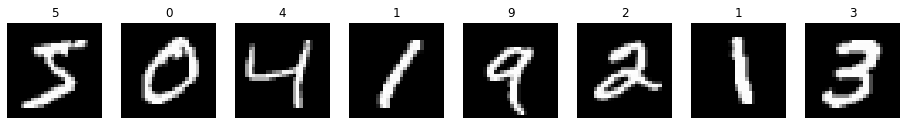

In [5]:
from tensorflow import keras
layers = keras.layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# escalamos a [0, 1] y agregamos la dimensión de canales: (28, 28) -> (28, 28, 1)
x_train = x_train[..., None].astype("float32") / 255
x_test = x_test[..., None].astype("float32") / 255

print("train:", x_train.shape, "test:", x_test.shape)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for ax, imagen, etiqueta in zip(axes, x_train, y_train):
    ax.imshow(imagen[..., 0], cmap="gray")
    ax.set_title(etiqueta)
    ax.axis("off")

## El modelo

In [6]:
cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
])
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dropout (Dropout)           (None, 1600)              0

2026-10-06 20:10:53.508379: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


* ¿De dónde sale cada forma de salida? ¿Y cada cantidad de parámetros?
* Conv 1: 32 x (3x3x1 + 1) = 320. Conv 2: 64 x (3x3x**32** + 1) = 18.496

### Comparemos con una red densa

In [7]:
densa = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
densa.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               100480    
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


## Entrenamiento

In [8]:
cnn.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = cnn.fit(x_train, y_train, batch_size=128, epochs=3, validation_split=0.1)

loss, accuracy = cnn.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy:.4f}")

Epoch 1/3
422/422 [==============================] - 27s 60ms/step - loss: 0.3705 - accuracy: 0.8858 - val_loss: 0.0820 - val_accuracy: 0.9795
Epoch 2/3
422/422 [==============================] - 23s 55ms/step - loss: 0.1120 - accuracy: 0.9661 - val_loss: 0.0531 - val_accuracy: 0.9865
Epoch 3/3
422/422 [==============================] - 21s 50ms/step - loss: 0.0864 - accuracy: 0.9734 - val_loss: 0.0462 - val_accuracy: 0.9888
Accuracy en test: 0.9864


## ¿Qué aprendió? Los filtros de la primera capa

forma de los filtros: (3, 3, 1, 32)


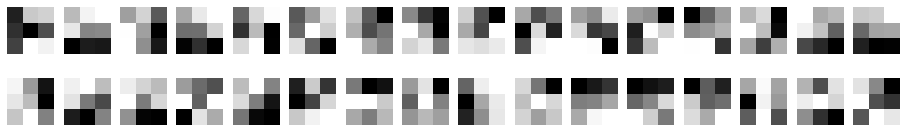

In [9]:
filtros, bias = cnn.layers[0].get_weights()
print("forma de los filtros:", filtros.shape)  # (alto, ancho, canales_entrada, cantidad_filtros)

fig, axes = plt.subplots(2, 16, figsize=(16, 2.4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(filtros[:, :, 0, i], cmap="gray")
    ax.axis("off")

### Y los feature maps que generan para un dígito

forma de los feature maps: (26, 26, 32)


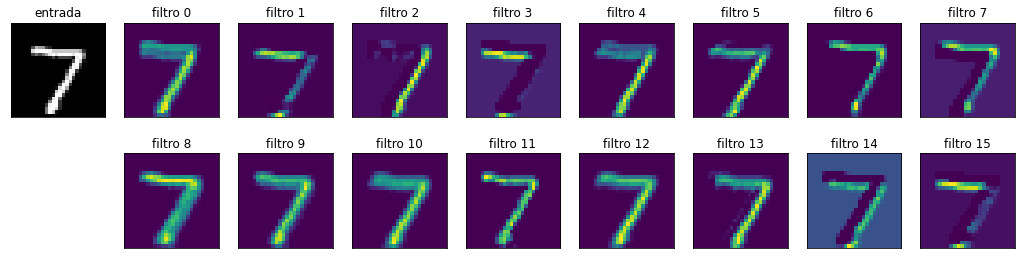

In [10]:
extractor = keras.Model(inputs=cnn.inputs, outputs=cnn.layers[0].output)
feature_maps = extractor.predict(x_test[:1], verbose=0)[0]
print("forma de los feature maps:", feature_maps.shape)

fig, axes = plt.subplots(2, 9, figsize=(18, 4.4))
axes[0, 0].imshow(x_test[0, ..., 0], cmap="gray")
axes[0, 0].set_title("entrada")
axes[1, 0].axis("off")
for i, ax in enumerate(axes[:, 1:].ravel()):
    ax.imshow(feature_maps[..., i], cmap="viridis")
    ax.set_title(f"filtro {i}")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

# Data augmentation

## ¿Qué es?

* Generar ejemplos nuevos a partir de los existentes, aplicando transformaciones que **no cambian la etiqueta**: rotar, espejar, hacer zoom, recortar, cambiar brillo o contraste, agregar ruido...

## ¿Para qué?

* Para tener "más datos" sin etiquetar nada nuevo, y **reducir el sobreentrenamiento**
* Para enseñarle a la red las **invariancias** que queremos (un perro sigue siendo un perro si está espejado)

## ¿Cómo?

* En Keras, con capas de preprocesamiento (`RandomFlip`, `RandomRotation`, `RandomZoom`, ...) que **sólo actúan durante el entrenamiento**
* Ojo con transformaciones que **sí** cambian la etiqueta: espejar un 6 o rotar 180° un 9, espejar texto, etc.

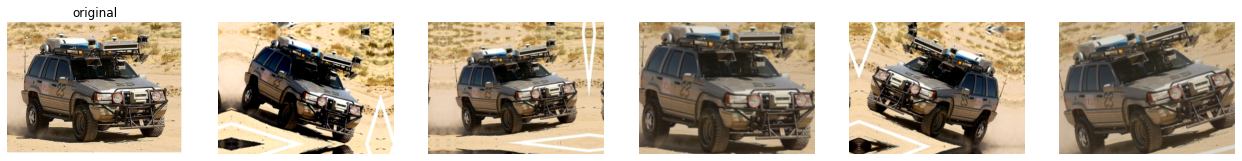

In [11]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.25),
    layers.RandomContrast(0.4),
])

foto = np.asarray(Image.open("images/cnn_demo_photo.jpg"), dtype="float32") / 255

fig, axes = plt.subplots(1, 6, figsize=(22, 3.6))
axes[0].imshow(foto)
axes[0].set_title("original")
aumentadas = augmentation(np.repeat(foto[None], 5, axis=0), training=True)  # 5 copias, una transformación distinta a cada una
for ax, aumentada in zip(axes[1:], np.asarray(aumentadas)):
    ax.imshow(np.clip(aumentada, 0, 1))
for ax in axes:
    ax.axis("off")

Para usarlo, se agrega como primeras capas del modelo:

```python
modelo = keras.Sequential([
    keras.Input(shape=(alto, ancho, 3)),
    augmentation,          # sólo transforma durante fit(), no al predecir
    layers.Conv2D(...),
    ...
])
```

Más info: https://keras.io/guides/preprocessing_layers/

# Transfer Learning

## ¿Qué es?

* Tomar un modelo entrenado para la tarea *A* y reutilizarlo para hacer la tarea *B*

## ¿Por qué funciona?

* Las primeras capas de una CNN aprenden features **genéricas** (bordes, colores, texturas, formas) que sirven para casi cualquier imagen
* Sólo las últimas capas son **específicas** de la tarea original

## ¿Para qué?

* Principalmente, para evitar conseguir y/o etiquetar un dataset enorme: con **cientos** de imágenes por clase se pueden lograr buenos resultados
* Beneficio adicional: nos ahorramos mucho poder de cómputo en el entrenamiento (entrenar en ImageNet lleva días de GPU)

## ¿Cómo?

<div><img src="images/transfer_learning.jpg" width="75%"></div>

1. Buscamos un modelo **preentrenado** (normalmente en ImageNet: 1,2 millones de imágenes, 1.000 clases)
2. **Reemplazamos las capas finales** por unas nuevas, con la cantidad de clases de nuestro problema
3. **Congelamos** (*freeze*) las capas iniciales y entrenamos sólo las nuevas → *feature extraction*
4. Cuando el aprendizaje se estanca, podemos **descongelar** las últimas capas del modelo base y seguir entrenando con un learning rate **bajo** → **fine tuning**

## ¿Cuánto congelar?

| | Datos parecidos a ImageNet | Datos muy distintos (médicas, satelitales...) |
|---|---|---|
| **Pocos datos** | congelar todo, entrenar sólo la cabeza | congelar menos capas, con cuidado del overfitting |
| **Muchos datos** | fine tuning de las últimas capas | fine tuning de gran parte de la red |

## Modelos y ejemplos típicos

**Modelos preentrenados** (disponibles en `keras.applications`, PyTorch/torchvision, Hugging Face Hub):

* VGG16, ResNet50, Inception, MobileNet (liviano, para celulares), EfficientNet
* No sólo imágenes: YAMNet o PANNs para audio, BERT o GPT para texto

**Ejemplos de aplicación**:

* Diagnóstico por imágenes médicas (radiografías, lesiones de piel)
* Detección de enfermedades en hojas de cultivos, conteo de plantas en imágenes de drones
* Control de calidad en líneas de producción (detección de defectos)
* Clasificación de comida: ver `transfer_learning/Transfer learning con VGG16.ipynb` (Food-101)

### Un modelo preentrenado "tal cual"

MobileNetV2 entrenado en ImageNet, sin cambiarle nada:

In [12]:
mobilenet = keras.applications.MobileNetV2(weights="imagenet")

imagen = keras.utils.load_img("images/cnn_demo_photo.jpg", target_size=(224, 224))
x = keras.applications.mobilenet_v2.preprocess_input(keras.utils.img_to_array(imagen)[None])

for _, clase, probabilidad in keras.applications.mobilenet_v2.decode_predictions(mobilenet.predict(x, verbose=0), top=5)[0]:
    print(f"{clase:25s} {probabilidad:.3f}")

jeep                      0.783
half_track                0.076
tow_truck                 0.017
ambulance                 0.008
beach_wagon               0.008


### Adaptándolo a nuestro problema (ej: 5 clases propias)

In [13]:
base = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,       # sin la capa final de 1.000 clases de ImageNet
    input_shape=(160, 160, 3),
    pooling="avg",           # global average pooling: un vector por imagen
)
base.trainable = False       # congelamos el modelo base

modelo = keras.Sequential([
    keras.Input(shape=(160, 160, 3)),
    layers.RandomFlip("horizontal"),         # data augmentation
    layers.RandomRotation(0.1),
    layers.Rescaling(1 / 127.5, offset=-1),  # MobileNetV2 espera valores en [-1, 1]
    base,
    layers.Dropout(0.2),
    layers.Dense(5, activation="softmax"),   # nuestra nueva "cabeza"
])
modelo.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip_1 (RandomFlip)  (None, 160, 160, 3)       0         
                                                                 
 random_rotation_1 (RandomRo  (None, 160, 160, 3)      0         
 tation)                                                         
                                                                 
 rescaling (Rescaling)       (None, 160, 160, 3)       0         
                                                                 
 mobilenetv2_1.00_160 (Funct  (None, 1280)             2257984   
 ional)                                                          
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_3 (Dense)             (None, 5)                

Sólo entrenamos ~6 mil de ~2,3 millones de parámetros. Para hacer **fine tuning** después:

```python
base.trainable = True
for capa in base.layers[:-30]:      # descongelamos sólo las últimas 30 capas
    capa.trainable = False

modelo.compile(optimizer=keras.optimizers.Adam(1e-5),   # learning rate bajo!
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo.fit(...)
```

# Modelos generativos en NLP

## Discriminativos vs generativos

* Todo lo que vimos hasta ahora es **discriminativo**: dado un input, predecir una etiqueta (¿es un 7? ¿es un jeep?)
* Un modelo **generativo** aprende a **producir** datos nuevos parecidos a los de entrenamiento: texto, imágenes, audio, código

Generación de texto

![](images/text1.png)

![](images/text2.png)

Generación de código

![](images/code.png)

## Language models: predecir el próximo token

Un **modelo de lenguaje** recibe una secuencia de tokens y devuelve, para **cada token del vocabulario**, la probabilidad de que sea el siguiente:

`"La clase de redes neuronales termina"` → `" tarde"`: 0.31, `" a"`: 0.22, `" con"`: 0.12, `" hoy"`: 0.07, ...

Para **generar** texto se repite el proceso:

1. Predecir la distribución del próximo token
2. Elegir uno (el más probable, o muestreando: la **temperatura** controla qué tan "creativo" es)
3. Agregarlo al input y volver a 1

Un LLM es, en esencia, este loop. Todo lo que escribe sale de predecir **un token por vez**.

## Un poco de historia

* Language models hay desde hace rato: n-gramas (contar qué palabra sigue a cuál), y luego redes recurrentes (RNNs, LSTMs), que leían el texto **de a un token**, arrastrando una "memoria" de lo anterior. Problemas: lentas de entrenar (no paralelizables) y les costaba recordar contexto lejano (gradientes que se desvanecen)
* 2017, **Transformers** ("Attention is all you need"): ya no recurrentes. Miran **todo el texto a la vez**, y parte de la red (el mecanismo de **atención**) decide en qué tokens enfocarse para cada predicción
* Eso permitió paralelizar, escalar a modelos y datasets gigantes, y ampliar la ventana de contexto (GPT-3: 2.048 tokens; los modelos actuales: cientos de miles o más)

## ¿Cómo se entrenan los LLMs actuales?

1. **Preentrenamiento**: predecir el próximo token sobre volúmenes gigantes de texto (web, libros, código). No hace falta etiquetar: el target es el **próximo token del propio texto**, que la red no recibe como input (aprendizaje *auto-supervisado*)
2. **Ajuste con instrucciones**: fine tuning con ejemplos de pregunta → respuesta, para que se comporte como un asistente
3. **Ajuste con preferencias humanas** (ej: RLHF): personas comparan respuestas y el modelo aprende a preferir las mejores

¿Les suena? Es **transfer learning** a gran escala: un modelo base enorme, adaptado después a tareas específicas

## En los LLMs actuales

* Es todo predicción de próximo token. A veces con pasos extra (ej: "razonar" en voz alta antes de responder)
* Inputs: cadena de tokens. Output: para cada token existente, la probabilidad de venir luego del input
* Muy potentes, pero también muy costosos de entrenar y de usar. Se buscan mejoras de eficiencia (Mixture of Experts, multi-token prediction, modelos más chicos y especializados, etc.)
* Limitaciones: pueden **"alucinar"** (generar algo plausible pero falso), reproducir **sesgos** de los datos, y no "saben" nada posterior a sus datos de entrenamiento

## Para seguir explorando

* El detalle de los transformers lo van a ver en otra materia
* Mismo equipo que CNN Explainer: https://poloclub.github.io/transformer-explainer/
* Visualización 3D de un LLM, paso a paso: https://bbycroft.net/llm

# Cierre

* Los datos **no estructurados** son tensores enormes de valores crudos, sin features con significado y con **estructura local** (espacial, temporal, secuencial)
* El enfoque tradicional diseñaba features a mano; el **deep learning** las aprende de los datos crudos
* Las **CNN** aprovechan la estructura espacial con **filtros** chicos de pesos compartidos que generan **feature maps**, y construyen una **jerarquía** de features
* **Pooling** reduce tamaño, **dropout** y **data augmentation** combaten el overfitting
* **Transfer learning**: reutilizar lo que aprendió un modelo grande, con pocos datos y poco cómputo
* Los **LLMs** son modelos de lenguaje que predicen el próximo token, preentrenados a gran escala y luego ajustados